# W03A - Metropolis Monte Carlo Optimization

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Task 1 - plotting

Text(0.02, 0.5, 'Potential Energy V(x)')

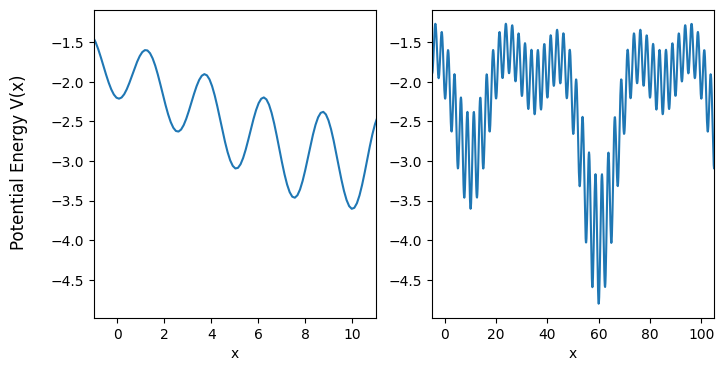

In [4]:
def V(x):
    return (-1 -np.exp (-((x+15) /10) **2) \
            -2*np.exp (-((x -10) /10) **2) + \
            -np.exp (-((x -35) /10) **2) \
            -3*np.exp (-((x -60) /10) **2) \
            -np.exp (-((x -85) /10) **2)\
            -2*np.exp (-((x -110) /10) **2) \
            ) * \
            (1+1/5* np.cos (2* np.pi /2.5*x))

xs = np.linspace(-5,105,1000)
fig, axes = plt.subplots(1,2,figsize=(8,4))
for ax in axes:
    ax.plot(xs, V(xs))
    ax.set_xlabel('x')
axes[0].set_xlim(-1,11)
axes[1].set_xlim(-5,105)
fig.supylabel('Potential Energy V(x)')

### Task 2
Use the Metropolis Monte Carlo method to create a Markov chain trajectory at two different
temperatures

In [282]:
class System():

    def __init__(self, n_steps = 1, kT=1/3, xmin=-1, xmax=11, x=0, delta=0.1):
        self.kT = kT
        self.xmin = xmin
        self.xmax = xmax
        self.n_steps = n_steps

        self.xopt = 0
        self.yopt = 0

        self.x = x
        self.delta = delta

        self.energy = self.get_V(self.x)
        self.states = self.run_Metropolis_Monte_Carlo()
        
        self.xspace = np.linspace(self.xmin, self.xmax, 100)
        self.energies = self.get_V(self.xspace)

    def get_V(self, x):
        return V(x)

    def proposed_x(self):
        p_x = self.x + np.random.normal(0, self.delta)
        if p_x < self.xmin:
            p_x = self.xmin
        if p_x > self.xmax:
            p_x = self.xmax
        return p_x
    
    def step(self):
        proposed_x = self.proposed_x()
        proposed_energy = self.get_V(proposed_x)
        delta_E = proposed_energy - self.energy
        acceptance_probability = min(1, np.exp(-delta_E / self.kT))  # using P(x')/P(x) = exp(-E'/kT)/exp(E/kT) = exp(-delta_E/kT)
        # a clever way to choose randomly given a probability
        # if acceptance_probability=0.4, it is chosen 40% of times.
        if np.random.rand() < acceptance_probability:
            self.x = proposed_x
            self.energy = proposed_energy
    
    def run_Metropolis_Monte_Carlo(self):
        states = []
        states.append((self.x, self.get_V(self.x)))
        for _ in range(self.n_steps):
            self.step()
            energy = self.get_V(self.x)
            states.append((self.x, energy))
            if energy < self.yopt:
                self.xopt = self.x
                self.yopt = energy
        return states

    def plot(self, axes, title):
        x_points, y_points = zip(*self.states)

        axes[0].plot(x_points,range(len(x_points)),'-',color='k')
        for i, x in enumerate(x_points):
            axes[0].plot(x,i, '.',ms=12)
        
        axes[1].plot(xs, V(xs), color='k')
        for x, y in zip(x_points, y_points):
            axes[1].plot(x,y,'.', ms=12)

        for ax in axes:
            ax.set_xlim(-1,11)
        axes[1].set_ylim(-4,-1)

        axes[0].set_title(title)
        axes[0].set_ylabel('Monte Carlo time')
        axes[1].set_ylabel('Potential Energy V(x)')
        axes[1].set_xlabel('x')

    def big_plot(self, ax):
        x_points, y_points = zip(*self.states)
        ax.plot(xs, V(xs))
        ax.plot(x_points, y_points, '.-', color='k', ms=6)
        print(self.xopt, self.yopt)
        ax.scatter(self.xopt, self.yopt, color='red', s=100)
        # ax.plot(x_points[::self.n_steps//20], y_points[::self.n_steps//20], '.-', color='k', ms=6)


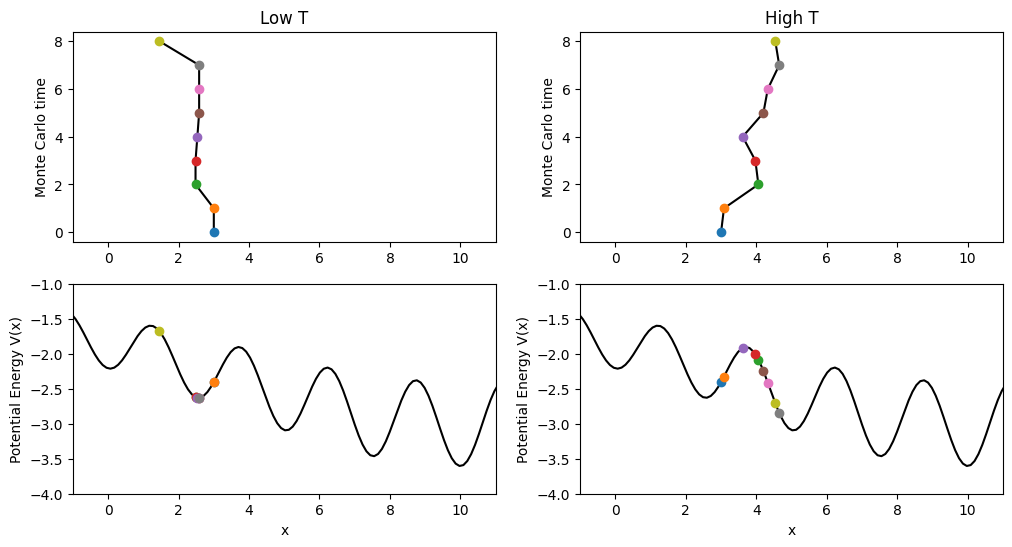

In [161]:
s_lowT = System(n_steps=8, kT=0.5, x=3, delta=0.5)
s_highT = System(n_steps=8, kT=10, x=3, delta=0.5)

fig, axes = plt.subplots(2,2,figsize=(12,6))
s_lowT.plot((axes[0,0], axes[1,0]), 'Low T')
s_highT.plot((axes[0,1], axes[1,1]), 'High T')

It appears that with this parameter for delta=0.5, the higher temperature is capable to "jump" the peaks and escape the potential.

### Task 3+4
Make some number of walkers and observe their ability to identify the global minimum

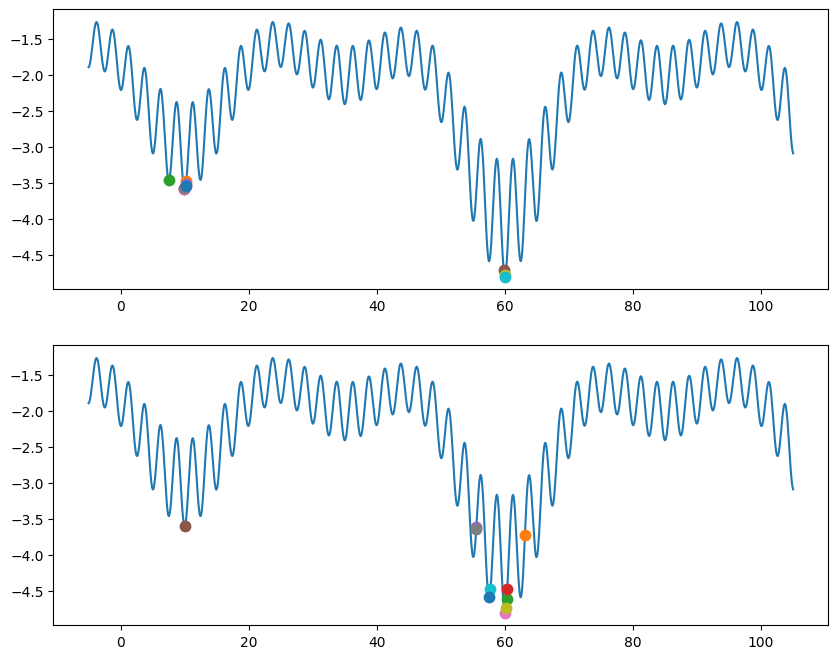

In [365]:
fig, axes = plt.subplots(2,1,figsize=(10,8))
for ax in axes:
    ax.plot(xs, V(xs))
for _ in range(10):
    s_lowT = System(n_steps=100, kT=0.5, x=3, xmin=-5, xmax=105, delta=8)
    s_highT = System(n_steps=100, kT=5, x=3, xmin=-5, xmax=105, delta=8)
    axes[0].plot(s_lowT.xopt, s_lowT.yopt, '.', ms=15)
    axes[1].plot(s_highT.xopt, s_highT.yopt, '.', ms=15)


It appears that more walkers find their way to the global minimum when the temperature increases.

59.887520723037106 -4.772403294427527


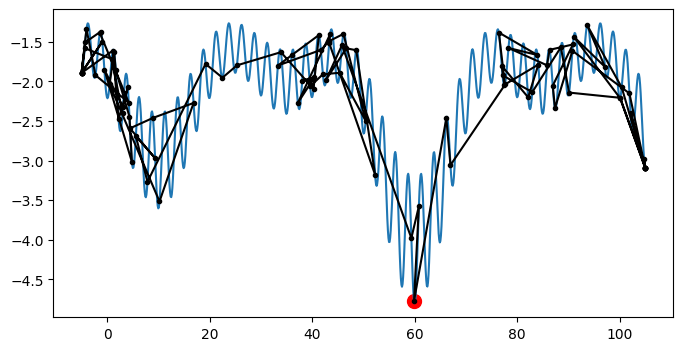

In [330]:
s_highT = System(n_steps=100, kT=10, x=3, xmin=-5, xmax=105, delta=5)
fig, ax = plt.subplots(1,1,figsize=(8,4))
s_highT.big_plot(ax)

# W03B - The Morse potential

### Task 1
Plot the potential

In [2]:
class System():
    def __init__(self, r0=1, eps=3/2, a=2):
        self.r0 = r0
        self.eps = eps
        self.a = a

        self.rs = np.linspace(0.1, 4, 100)
        self.morse_pot = self.get_pot(self.rs)

    def get_pot(self, r):
        return self.eps * ((1 - np.exp(-self.a*(r-self.r0)))**2 - 1)

    def plot_pot(self, ax):
        ax.plot(self.rs, self.morse_pot)
        ax.set_ylim(-2, 5)
        ax.grid()
    

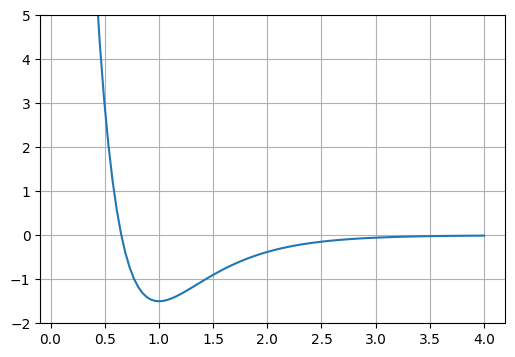

In [5]:
s = System()
fig, ax = plt.subplots(1,1,figsize=(6,4))
s.plot_pot(ax)

### Task 2

Get potential energy using a calculator

In [7]:
from scipy.spatial.distance import pdist
class Calculator ():
    def potential_energy (self , pos):
        return np.sum(self._V(pdist(pos)))

class Morse(Calculator):

    a = 2
    eps = 3/2
    r0 = 1

    def _V(self, r):
        return self.eps * ((1 - np.exp(-self.a*(r-self.r0)))**2 - 1)

morse = Morse()

pos = np.array ([[0 , 0], [3/2 , 0], [0, 1]])

print(f'{morse.potential_energy(pos):.2f}')

-2.94


### Task 3
Implement the calculator to a cluster class

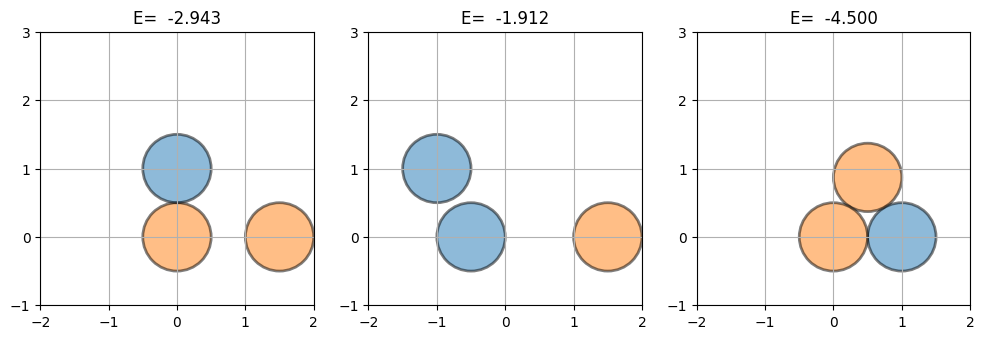

In [53]:
import matplotlib .pyplot as plt
from week03 import nice_plot, AtomicClusterBase


class AtomicCluster(AtomicClusterBase):
    @property
    def potential_energy(self):
        return self.calc.potential_energy(self.pos)
    # combine self.calc and self.pos to return the potential energy of the cluster

fig , axes = plt.subplots (1,3, figsize =(12 ,4))

cluster0 = AtomicCluster(morse, pos = [[0 , 0], [3/2 , 0], [0, 1]], static = [True, True, False])
cluster1 = AtomicCluster(morse, pos = [[-1/2 , 0], [3/2 , 0], [-1, 1]], static = [False, True, False])
cluster2 = AtomicCluster(morse, pos = [[1 , 0], [1/2 , 0.87], [0, 0]], static = [False, True, True])
for ax , cluster in zip(axes, [cluster0, cluster1, cluster2]):  
    cluster.draw(ax)
    nice_plot(ax)

### Task 4
Make a contour plot

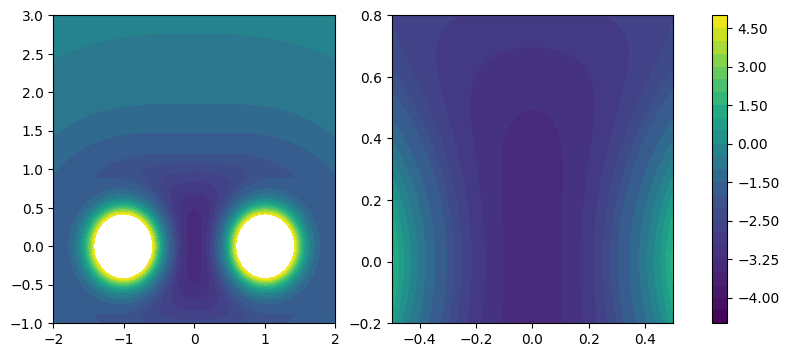

In [54]:
p0 = [0,0]
p1 = [-1,0]
p2 = [1,0]
pos0 = np.array([p0, p1, p2])
cluster = AtomicCluster(morse, pos = pos0, static = [True, False, False])
fig, axes = plt.subplots(1,2, figsize=(10,4))

xs = np.linspace(-2, 2, 100)
ys = np.linspace(-1, 3, 100)

xd, yd = np.meshgrid(xs,ys)
zd = np.zeros(xd.shape)

for i, j in np.ndindex(xd.shape): #run through xd like a matrix:
    cluster.pos = np.array([[xd[i, j],yd[i, j]], p1, p2])
    zd[i,j] = cluster.potential_energy    # get the energy into the contour plot for position i, j

levels = list(np.arange(-4.5, -2, step=0.25)) + list(np.arange(-2, 5.001, 0.5))

for ax in axes:
    cf = ax.contourf(xd, yd, zd, levels=levels)

axes[1].set_ylim(-0.2,0.8)
axes[1].set_xlim(-0.5,0.5)

fig.colorbar(cf, ax=axes)

### Task 5



21


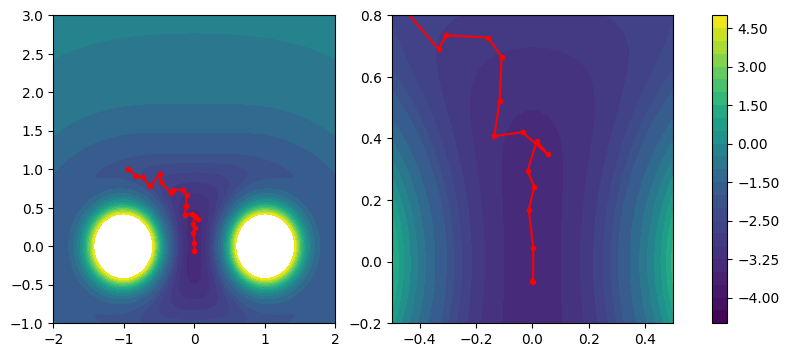

In [106]:
class AtomicClusterWithRattleOfFirstAtom(AtomicCluster):
    def rattle_first_atom(self, A=0.1):
        index = 0
        delta_r = [np.random.normal(0, A), np.random.normal(0,A)]
        self.pos[index, :] += delta_r

cluster = AtomicClusterWithRattleOfFirstAtom(morse, pos=np.array([[-1,1.2],[-1,0],[1,0]]),  static = [True, False, False])

def monte_carlo_quench(cluster, Nsteps):
    visited_positions = []
    for _ in range(Nsteps):
        test = cluster.copy()
        test.rattle_first_atom()
        delta_e = test.potential_energy - cluster.potential_energy
        #print(test.potential_energy, cluster)
        # in the limit T -> 0, all steps that increase energy are rejected
        if delta_e < 0:
            # let cluster get the positions of test
            cluster.set_positions(test.get_positions())
            visited_positions.append(test.get_positions()[0])
    return visited_positions

visited = monte_carlo_quench(cluster=cluster, Nsteps=300)
print(len(visited))
xpos, ypos = zip(*visited)

fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax in axes:
    ax.plot(xpos,ypos,'.-', color='red')
    cf = ax.contourf(xd, yd, zd, levels=levels)

axes[1].set_ylim(-0.2,0.8)
axes[1].set_xlim(-0.5,0.5)

fig.colorbar(cf, ax=axes)

### Task 6

Why would moving test = cluster.copy() outside the for loop not work?

The first copy test (copy) would be some crazy move, and then the monte carlo probabibly won't accept it, and the cluster 1st position doesn't change. In the next iteration, test.rattle_first_atom() rattles the crazy position, and NOT where the 1st position in cluster actually is. Then we take another crazy step, perhaps also in the wrong direction, we don't accept it, and now test is very far away from the minimum.

At some point, the step might be accepted, but the overall rattles would cause the path to almost randomly walk around the potential surface.

30


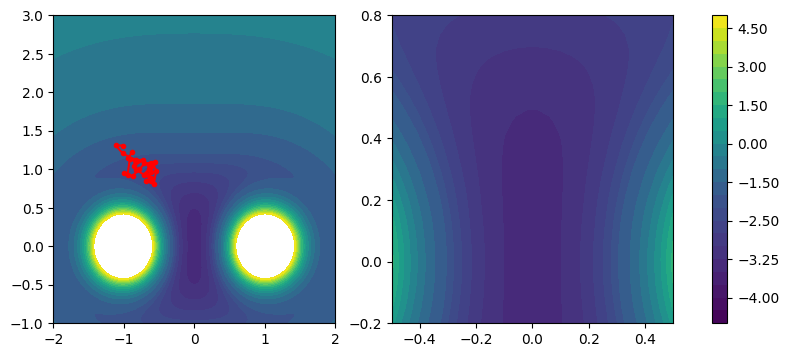

In [109]:
cluster = AtomicClusterWithRattleOfFirstAtom(morse, pos=np.array([[-1,1.2],[-1,0],[1,0]]),  static = [True, False, False])

def monte_carlo_quench(cluster, Nsteps):
    visited_positions = []
    test = cluster.copy()
    for _ in range(Nsteps):
        test.rattle_first_atom()
        delta_e = test.potential_energy - cluster.potential_energy
        #print(test.potential_energy, cluster)
        # in the limit T -> 0, all steps that increase energy are rejected
        visited_positions.append(test.get_positions()[0])
        if delta_e < 0:
            # let cluster get the positions of test
            cluster.set_positions(test.get_positions())
    return visited_positions

visited = monte_carlo_quench(cluster=cluster, Nsteps=30)
print(len(visited))
xpos, ypos = zip(*visited)

fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax in axes:
    ax.plot(xpos,ypos,'.-', color='red')
    cf = ax.contourf(xd, yd, zd, levels=levels)

axes[1].set_ylim(-0.2,0.8)
axes[1].set_xlim(-0.5,0.5)

fig.colorbar(cf, ax=axes)

Here I show what that would look like. The returned positions are not the actual cluster moving, because probably not that many would be accepted. This is the path of test.